In [1]:
# ============================================================
# Step 1. Load the human-converted Paul15 dataset
# ============================================================

import scanpy as sc
import pandas as pd
import numpy as np

# Load dataset
adata = sc.read_h5ad("sample_data/human_paul15_subset.h5ad")

print("Dataset loaded successfully!\n")
print(adata)

print(f"\nNumber of cells : {adata.n_obs}")
print(f"Number of genes : {adata.n_vars}")

Dataset loaded successfully!

AnnData object with n_obs × n_vars = 800 × 2953
    obs: 'cell_type'
    var: 'human_gene'
    uns: 'gene_conversion'

Number of cells : 800
Number of genes : 2953


In [2]:
# ============================================================
# Step 2. Inspect cell types and gene metadata
# ============================================================

print("Cell-type categories:")
print(adata.obs["cell_type"].value_counts())

print("\nFirst 10 observation records:")
display(adata.obs.head(10))

print("\nFirst 10 variable records:")
display(adata.var.head(10))

print("\nFirst 20 human gene symbols:")
print(adata.var_names[:20].tolist())

print("\nAre gene names unique?")
print(adata.var_names.is_unique)

print("\nMissing human gene symbols:")
print(adata.var_names.isna().sum())

Cell-type categories:
cell_type
14Mo       107
2Ery        89
3Ery        85
13Baso      80
5Ery        64
6Ery        58
15Mo        57
7MEP        48
16Neu       47
10GMP       38
4Ery        35
8Mk         20
1Ery        15
9GMP        14
12Baso      12
19Lymph     12
11DC        11
17Neu        4
18Eos        4
Name: count, dtype: int64

First 10 observation records:


,cell_type
W31732,13Baso
W38637,3Ery
W39126,10GMP
W31177,5Ery
W36930,15Mo
W31603,16Neu
W31361,16Neu
W38561,10GMP
W39116,10GMP
W38152,7MEP



First 10 variable records:


,human_gene
C9orf85,C9orf85
C19orf12,C19orf12
C11orf97,C11orf97
C17orf50,C17orf50
C11orf98,C11orf98
C1orf198,C1orf198
C22orf39,C22orf39
LINC00673,LINC00673
KIAA1671,KIAA1671
C5orf22,C5orf22



First 20 human gene symbols:
['C9orf85', 'C19orf12', 'C11orf97', 'C17orf50', 'C11orf98', 'C1orf198', 'C22orf39', 'LINC00673', 'KIAA1671', 'C5orf22', 'C5orf15', 'C19orf38', 'C16orf54', 'AAK1', 'ABCA3', 'ABCB10', 'ABCB1', 'ABCB4', 'ABCB6', 'ABCB9']

Are gene names unique?
True

Missing human gene symbols:
0


In [3]:
# ============================================================
# Step 3. Configure the cell annotation workflow
# ============================================================

USE_SAMPLE_DATA = False

# Use the human-converted Paul15 dataset
MY_REFERENCE_H5AD = "human_paul15_subset.h5ad"
MY_QUERY_H5AD = "human_paul15_subset.h5ad"

# Metadata and gene-symbol columns
LABEL_KEY = "cell_type"
GENE_COL = "human_gene"

# CPU inference settings
N_CELLS = 50
N_NEIGHBORS = 15

print("Cell annotation configuration")
print("--------------------------------")
print("Reference dataset :", MY_REFERENCE_H5AD)
print("Query dataset     :", MY_QUERY_H5AD)
print("Label column      :", LABEL_KEY)
print("Gene column       :", GENE_COL)
print("Cells per dataset :", N_CELLS)
print("kNN neighbors     :", N_NEIGHBORS)

Cell annotation configuration
--------------------------------
Reference dataset : human_paul15_subset.h5ad
Query dataset     : human_paul15_subset.h5ad
Label column      : cell_type
Gene column       : human_gene
Cells per dataset : 50
kNN neighbors     : 15


In [4]:
# ============================================================
# Step 4. Import required packages
# ============================================================

import os
import warnings
import random

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

import torch

warnings.filterwarnings("ignore")

print("=" * 60)
print("Environment Information")
print("=" * 60)

print(f"Python : {os.sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Scanpy : {sc.__version__}")

print(f"CUDA available: {torch.cuda.is_available()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Running on: {device}")

Environment Information
Python : 3.10.20
PyTorch: 2.3.1
Scanpy : 1.11.5
CUDA available: False
Running on: cpu


In [5]:
# ============================================================
# Step 5. Check the scGPT installation
# ============================================================

import scgpt

print("=" * 60)
print("scGPT Information")
print("=" * 60)

print("scGPT version:", getattr(scgpt, "__version__", "Unknown"))

print("\nscGPT package loaded successfully.")

scGPT Information
scGPT version: 0.2.4

scGPT package loaded successfully.


In [6]:
# ============================================================
# Step 6. Define utility functions for low-memory scGPT inference
# ============================================================

import io
import os
import gc
import time
import contextlib
import warnings
from pathlib import Path

import numpy as np
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")
matplotlib.rcParams["axes.unicode_minus"] = False

# Disable external experiment tracking
os.environ.setdefault("WANDB_MODE", "disabled")

# Reduce unnecessary Scanpy output
sc.settings.verbosity = 0

# Limit CPU threads to reduce memory pressure
torch.set_num_threads(2)


def find_sample_data(filename):
    """
    Search for the requested file in the sample_data directory
    and in parent directories.
    """
    current_dir = Path.cwd().resolve()
    candidates = []

    for base_dir in [current_dir, *current_dir.parents]:
        candidates.extend([
            base_dir / "sample_data",
            base_dir
        ])

    for candidate in candidates:
        if (candidate / filename).exists():
            return candidate

    return current_dir / "sample_data"


def ensure_model_weights():
    """
    Check whether the pretrained scGPT model files are available.
    """
    from scgpt_rep import ensure_weights

    return ensure_weights()


def model_is_ready():
    """
    Return True if the pretrained scGPT model is available.
    """
    try:
        model_info = ensure_model_weights()
        return bool(model_info.get("ready"))

    except Exception:
        return False


def get_pretrained_model_directory():
    """
    Return the directory containing the pretrained human scGPT model.
    """
    model_info = ensure_model_weights()

    return model_info["scgpt_human_dir"]


def ensure_gene_column(adata, gene_column):
    """
    Ensure that adata.var contains a valid gene-symbol column.

    If the requested column is missing, create a new column
    using adata.var_names.
    """
    if gene_column and gene_column in adata.var.columns:
        return gene_column

    adata.var["gene_name"] = adata.var_names.astype(str)

    return "gene_name"


def subsample_cells(adata, number_of_cells):
    """
    Randomly subsample cells to reduce CPU memory usage.
    """
    if number_of_cells and adata.n_obs > number_of_cells:

        sc.pp.subsample(
            adata,
            n_obs=int(number_of_cells),
            random_state=0
        )

        print(
            f"Randomly selected {adata.n_obs} cells "
            "for low-memory CPU inference."
        )

    else:

        print(
            f"Using all {adata.n_obs} cells."
        )

    return adata


def clear_memory():
    """
    Release unused Python and PyTorch memory.
    """
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()


def generate_scgpt_cell_embeddings(
    adata,
    gene_column,
    batch_size=4
):
    """
    Generate scGPT cell embeddings using low-memory CPU settings.

    The resulting embeddings are stored in:

        adata.obsm["X_scGPT"]
    """
    from scgpt.tasks import embed_data

    clear_memory()

    gene_column = ensure_gene_column(
        adata,
        gene_column
    )

    captured_output = io.StringIO()

    with contextlib.redirect_stdout(captured_output), \
         contextlib.redirect_stderr(captured_output):

        output_adata = embed_data(
            adata,
            get_pretrained_model_directory(),
            gene_col=gene_column,
            batch_size=batch_size,
            device="cpu",
            use_fast_transformer=False,
            return_new_adata=False
        )

    for line in captured_output.getvalue().splitlines():

        if "match" in line.lower() and "vocab" in line.lower():

            print(
                "scGPT:",
                line.split(" - ")[-1].strip()
            )

    clear_memory()

    return output_adata


def plot_scgpt_umap(
    adata,
    representation,
    color_columns,
    title_prefix
):
    """
    Compute and plot a UMAP using a selected representation.
    """
    adata_plot = adata.copy()

    sc.pp.neighbors(
        adata_plot,
        use_rep=representation
    )

    sc.tl.umap(adata_plot)

    valid_columns = [
        column
        for column in color_columns
        if column in adata_plot.obs.columns
    ]

    titles = [
        f"{title_prefix}: {column}"
        for column in valid_columns
    ]

    sc.pl.umap(
        adata_plot,
        color=valid_columns,
        title=titles,
        frameon=False,
        wspace=0.4,
        show=True
    )

    return adata_plot


print("Low-memory utility functions initialized successfully.")
print("CPU threads:", torch.get_num_threads())
print("Pretrained scGPT model ready:", model_is_ready())

Low-memory utility functions initialized successfully.
CPU threads: 2
Pretrained scGPT model ready: True


In [7]:
# ============================================================
# Step 7. Validate the input data and pretrained model
# ============================================================

# Resolve the reference and query file paths
reference_name = MY_REFERENCE_H5AD
query_name = MY_QUERY_H5AD

REFERENCE_PATH = find_sample_data(reference_name) / reference_name
QUERY_PATH = find_sample_data(query_name) / query_name

# Create an output directory
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("=" * 60)
print("Input Data Validation")
print("=" * 60)

# Check input files
print("\n1. Reference and query datasets")

reference_exists = REFERENCE_PATH.exists()
query_exists = QUERY_PATH.exists()

print(
    "Reference dataset:",
    REFERENCE_PATH,
    "->",
    "Found" if reference_exists else "Not found"
)

print(
    "Query dataset    :",
    QUERY_PATH,
    "->",
    "Found" if query_exists else "Not found"
)

if not reference_exists or not query_exists:
    raise FileNotFoundError(
        "One or more input datasets could not be found."
    )

# Load datasets for validation
reference_check = sc.read_h5ad(REFERENCE_PATH)
query_check = sc.read_h5ad(QUERY_PATH)

print("\n2. Dataset dimensions")
print("Reference shape:", reference_check.shape)
print("Query shape    :", query_check.shape)

# Check the pretrained model
print("\n3. Pretrained scGPT model")
print(
    "Model status:",
    "Ready" if model_is_ready() else "Not ready"
)

if not model_is_ready():
    raise RuntimeError(
        "The pretrained scGPT model is not ready."
    )

# Check the reference label column
print("\n4. Reference label column")

if LABEL_KEY in reference_check.obs.columns:
    number_of_cell_types = reference_check.obs[LABEL_KEY].nunique()

    print(f"Label column '{LABEL_KEY}' found.")
    print("Number of cell types:", number_of_cell_types)

else:
    raise KeyError(
        f"Label column '{LABEL_KEY}' was not found. "
        f"Available columns: {list(reference_check.obs.columns)}"
    )

# Check whether the query dataset also contains true labels
print("\n5. Query label column")

if LABEL_KEY in query_check.obs.columns:
    print(
        f"True labels are available in '{LABEL_KEY}'. "
        "Prediction accuracy can be evaluated."
    )

else:
    print(
        "The query dataset does not contain true labels. "
        "Predictions can still be generated, but accuracy "
        "cannot be calculated."
    )

# Check the gene-symbol column
print("\n6. Gene-symbol column")

for dataset_name, dataset in [
    ("Reference", reference_check),
    ("Query", query_check)
]:
    if GENE_COL in dataset.var.columns:
        print(
            f"{dataset_name}: gene column '{GENE_COL}' found."
        )
    else:
        print(
            f"{dataset_name}: gene column '{GENE_COL}' not found. "
            "Gene symbols will be obtained from var_names."
        )

print("\n7. Output directory")
print("Output directory:", OUTPUT_DIR.resolve())

print("\nValidation completed successfully.")

Input Data Validation

1. Reference and query datasets
Reference dataset: /workspace/sample_data/human_paul15_subset.h5ad -> Found
Query dataset    : /workspace/sample_data/human_paul15_subset.h5ad -> Found

2. Dataset dimensions
Reference shape: (800, 2953)
Query shape    : (800, 2953)

3. Pretrained scGPT model
Model status: Ready

4. Reference label column
Label column 'cell_type' found.
Number of cell types: 19

5. Query label column
True labels are available in 'cell_type'. Prediction accuracy can be evaluated.

6. Gene-symbol column
Reference: gene column 'human_gene' found.
Query: gene column 'human_gene' found.

7. Output directory
Output directory: /workspace/outputs

Validation completed successfully.


In [8]:
# ============================================================
# Step 8. Generate scGPT cell embeddings with low-memory settings
# ============================================================

import gc
import time
import torch
import scanpy as sc

# Release unused memory before inference
gc.collect()

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("=" * 60)
print("Generating scGPT Cell Embeddings")
print("=" * 60)

# Load the query dataset
adata_query = sc.read_h5ad(QUERY_PATH)

# Use a small subset for CPU inference
adata_query = subsample_cells(
    adata_query,
    N_CELLS
)

print(f"Input shape: {adata_query.shape}")

# Generate embeddings using a small batch size
start_time = time.time()

adata_query = generate_scgpt_cell_embeddings(
    adata_query,
    gene_column=GENE_COL,
    batch_size=4
)

elapsed_time = time.time() - start_time

print("\nEmbedding generation completed.")
print(f"Elapsed time: {elapsed_time:.1f} seconds")

if "X_scGPT" not in adata_query.obsm:
    raise KeyError(
        "The scGPT embedding was not found in adata_query.obsm."
    )

print("\nEmbedding matrix shape:")
print(adata_query.obsm["X_scGPT"].shape)

Generating scGPT Cell Embeddings
Randomly selected 50 cells for low-memory CPU inference.
Input shape: (50, 2953)
scGPT - INFO - match 2946/2953 genes in vocabulary of size 60697.

Embedding generation completed.
Elapsed time: 51.8 seconds

Embedding matrix shape:
(50, 512)


Computing UMAP from scGPT embeddings


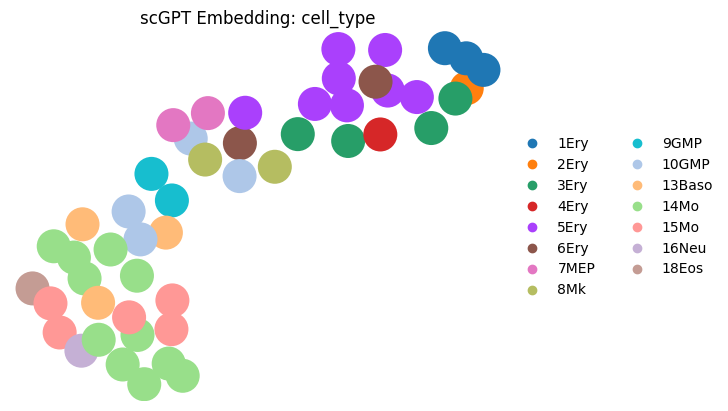


UMAP visualization completed.


In [9]:
# ============================================================
# Step 9. Visualize scGPT cell embeddings
# ============================================================

print("=" * 60)
print("Computing UMAP from scGPT embeddings")
print("=" * 60)

adata_embedding = plot_scgpt_umap(
    adata_query,
    representation="X_scGPT",
    color_columns=["cell_type"],
    title_prefix="scGPT Embedding"
)

print("\nUMAP visualization completed.")

In [10]:
# ============================================================
# Save the scGPT embedding UMAP
# ============================================================

import matplotlib.pyplot as plt

sc.pl.umap(
    adata_embedding,
    color="cell_type",
    title="scGPT Embedding: Cell Type",
    frameon=False,
    show=False
)

plt.savefig(
    "outputs/scGPT_Cell_Embedding_UMAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Figure saved successfully.")

Figure saved successfully.


In [13]:
# ============================================================
# Step 10. Perform kNN cell annotation without stratification
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Extract scGPT embeddings and cell-type labels
X = adata_query.obsm["X_scGPT"]
y = adata_query.obs[LABEL_KEY].astype(str).values

# Split cells without stratification because some cell types
# contain only one cell in the current 50-cell subset
X_reference, X_query, y_reference, y_query = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=None
)

# Use a small number of neighbors for the small reference set
n_neighbors = min(
    3,
    len(y_reference)
)

# Train the kNN classifier
knn = KNeighborsClassifier(
    n_neighbors=n_neighbors
)

knn.fit(
    X_reference,
    y_reference
)

# Predict cell types for the query subset
y_predicted = knn.predict(
    X_query
)

# Calculate prediction accuracy
accuracy = accuracy_score(
    y_query,
    y_predicted
)

# Store prediction results
annotation_results = pd.DataFrame({
    "true_cell_type": y_query,
    "predicted_cell_type": y_predicted
})

print("=" * 60)
print("Cell Annotation Results")
print("=" * 60)

print(f"Reference cells : {len(y_reference)}")
print(f"Query cells     : {len(y_query)}")
print(f"kNN neighbors   : {n_neighbors}")
print(f"Accuracy        : {accuracy:.3f}")

print("\nPredicted cell-type counts:")
display(
    annotation_results["predicted_cell_type"]
    .value_counts()
    .rename("Number of Cells")
    .to_frame()
)

print("\nFirst 10 predictions:")
display(annotation_results.head(10))

Cell Annotation Results
Reference cells : 30
Query cells     : 20
kNN neighbors   : 3
Accuracy        : 0.300

Predicted cell-type counts:


,Number of Cells
predicted_cell_type,
5Ery,5
15Mo,4
13Baso,4
10GMP,2
1Ery,2
14Mo,2
2Ery,1



First 10 predictions:


,true_cell_type,predicted_cell_type
0,10GMP,5Ery
1,5Ery,5Ery
2,14Mo,15Mo
3,13Baso,10GMP
4,1Ery,1Ery
5,14Mo,13Baso
6,14Mo,13Baso
7,14Mo,14Mo
8,7MEP,5Ery
9,9GMP,10GMP


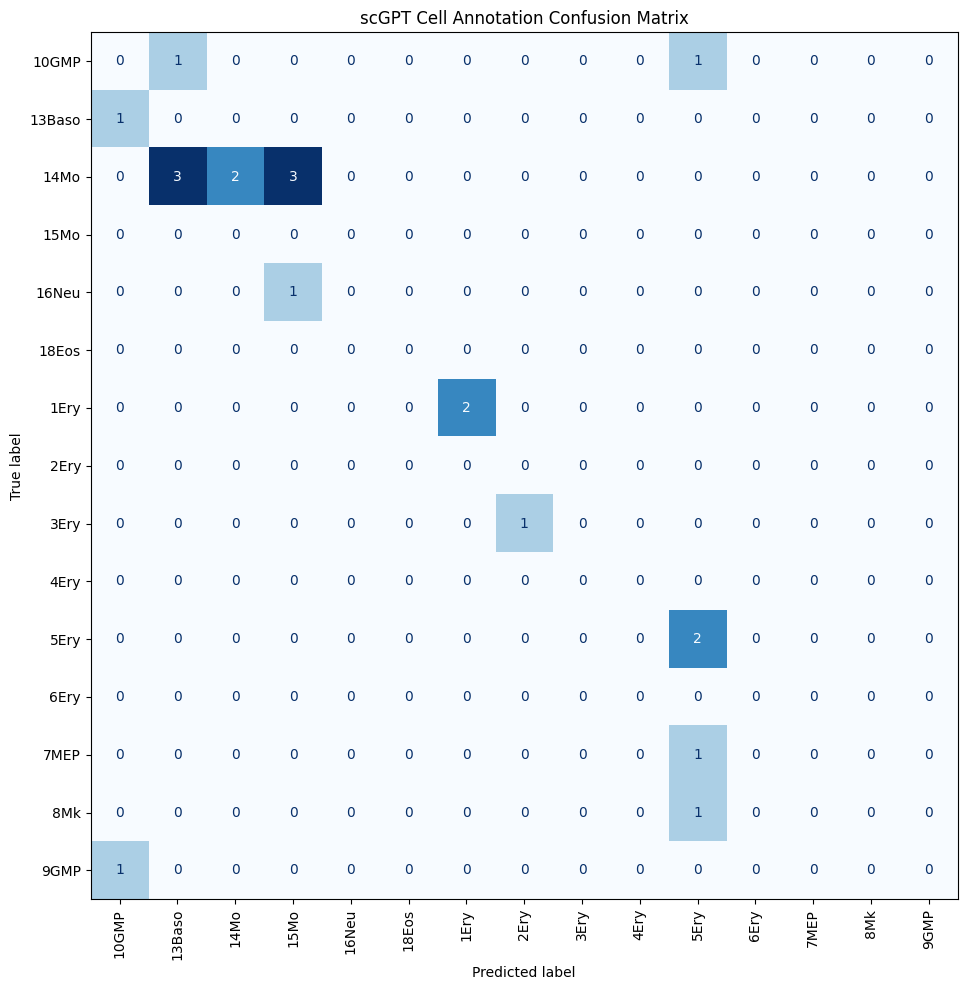

Confusion matrix saved to outputs/scGPT_confusion_matrix.png


In [14]:
# ============================================================
# Step 11. Plot confusion matrix
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

labels = sorted(np.unique(y))

cm = confusion_matrix(
    y_query,
    y_predicted,
    labels=labels
)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

plt.title("scGPT Cell Annotation Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "outputs/scGPT_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to outputs/scGPT_confusion_matrix.png")

In [15]:
# ============================================================
# Step 11. Save the annotated dataset
# ============================================================

import os

os.makedirs("outputs", exist_ok=True)

output_file = "outputs/scGPT_human_paul15_annotated.h5ad"

adata_query.write_h5ad(output_file)

print("=" * 60)
print("Annotated dataset saved successfully!")
print("=" * 60)
print(f"Output file: {output_file}")

Annotated dataset saved successfully!
Output file: outputs/scGPT_human_paul15_annotated.h5ad


In [16]:
# ============================================================
# Step 12. Final summary
# ============================================================

print("=" * 60)
print("scGPT Cell Annotation Pipeline Completed")
print("=" * 60)

print(f"Dataset shape      : {adata_query.shape}")
print(f"Embedding shape    : {adata_query.obsm['X_scGPT'].shape}")
print(f"Cell types         : {adata_query.obs[LABEL_KEY].nunique()}")
print(f"Prediction column  : predicted")
print(f"Embedding key      : X_scGPT")

print("\nOutputs generated:")
print("- scGPT_Cell_Embedding_UMAP.png")
print("- scGPT_confusion_matrix.png")
print("- scGPT_human_paul15_annotated.h5ad")

print("\nPipeline finished successfully.")

scGPT Cell Annotation Pipeline Completed
Dataset shape      : (50, 2946)
Embedding shape    : (50, 512)
Cell types         : 15
Prediction column  : predicted
Embedding key      : X_scGPT

Outputs generated:
- scGPT_Cell_Embedding_UMAP.png
- scGPT_confusion_matrix.png
- scGPT_human_paul15_annotated.h5ad

Pipeline finished successfully.


In [17]:
# ============================================================
# Step 13. Configure the scGPT batch integration workflow
# ============================================================

# Use the course multi-batch immune-cell dataset
USE_SAMPLE_DATA = True

# Dataset configuration
SAMPLE_H5AD_NAME = "Immune_ALL_human.h5ad"
MY_H5AD_NAME = "my_data.h5ad"

# Metadata columns
BATCH_KEY = "batch"
LABEL_KEY = "final_annotation"

# Gene-symbol column
GENE_COL = "gene_name"

# Low-memory CPU settings
N_CELLS = 50
BATCH_SIZE = 4

print("=" * 60)
print("scGPT Batch Integration Configuration")
print("=" * 60)

print(f"Use sample dataset : {USE_SAMPLE_DATA}")
print(f"Dataset            : {SAMPLE_H5AD_NAME}")
print(f"Batch column       : {BATCH_KEY}")
print(f"Cell-type column   : {LABEL_KEY}")
print(f"Gene column        : {GENE_COL}")
print(f"Number of cells    : {N_CELLS}")
print(f"Inference batch size: {BATCH_SIZE}")

scGPT Batch Integration Configuration
Use sample dataset : True
Dataset            : Immune_ALL_human.h5ad
Batch column       : batch
Cell-type column   : final_annotation
Gene column        : gene_name
Number of cells    : 50
Inference batch size: 4


In [18]:
# ============================================================
# Step 14. Initialize utilities for batch integration
# ============================================================

import os
import io
import gc
import time
import contextlib
import warnings
from pathlib import Path

import numpy as np
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")
matplotlib.rcParams["axes.unicode_minus"] = False

# Disable external experiment tracking
os.environ.setdefault("WANDB_MODE", "disabled")

# Reduce unnecessary Scanpy messages
sc.settings.verbosity = 0

# Limit CPU threads to reduce memory usage
torch.set_num_threads(2)


def find_sample_data(filename):
    """
    Search for the requested file in the sample_data directory
    and in parent directories.
    """
    current_dir = Path.cwd().resolve()
    candidates = []

    for base_dir in [current_dir, *current_dir.parents]:
        candidates.extend([
            base_dir / "sample_data",
            base_dir
        ])

    for candidate in candidates:
        if (candidate / filename).exists():
            return candidate

    return current_dir / "sample_data"


def ensure_model_weights():
    """
    Check whether the pretrained scGPT model files are available.
    """
    from scgpt_rep import ensure_weights

    return ensure_weights()


def model_is_ready():
    """
    Return True if the pretrained scGPT model is ready.
    """
    try:
        model_info = ensure_model_weights()
        return bool(model_info.get("ready"))

    except Exception:
        return False


def get_pretrained_model_directory():
    """
    Return the pretrained human scGPT model directory.
    """
    model_info = ensure_model_weights()

    return model_info["scgpt_human_dir"]


def ensure_gene_column(adata, gene_column):
    """
    Ensure that adata.var contains a valid gene-symbol column.

    If the requested column does not exist, use adata.var_names.
    """
    if gene_column and gene_column in adata.var.columns:
        return gene_column

    adata.var["gene_name"] = adata.var_names.astype(str)

    return "gene_name"


def subsample_cells(adata, number_of_cells):
    """
    Randomly subsample cells for low-memory CPU inference.
    """
    if number_of_cells and adata.n_obs > number_of_cells:

        sc.pp.subsample(
            adata,
            n_obs=int(number_of_cells),
            random_state=0
        )

        print(
            f"Randomly selected {adata.n_obs} cells "
            "for low-memory CPU inference."
        )

    else:

        print(
            f"Using all {adata.n_obs} cells."
        )

    return adata


def clear_memory():
    """
    Release unused Python and PyTorch memory.
    """
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()


def generate_scgpt_cell_embeddings(
    adata,
    gene_column,
    batch_size=4
):
    """
    Generate 512-dimensional scGPT cell embeddings.

    The embeddings are stored in:

        adata.obsm["X_scGPT"]
    """
    from scgpt.tasks import embed_data

    clear_memory()

    gene_column = ensure_gene_column(
        adata,
        gene_column
    )

    captured_output = io.StringIO()

    with contextlib.redirect_stdout(captured_output), \
         contextlib.redirect_stderr(captured_output):

        output_adata = embed_data(
            adata,
            get_pretrained_model_directory(),
            gene_col=gene_column,
            batch_size=batch_size,
            device="cpu",
            use_fast_transformer=False,
            return_new_adata=False
        )

    for line in captured_output.getvalue().splitlines():

        if "match" in line.lower() and "vocab" in line.lower():

            print(
                "scGPT:",
                line.split(" - ")[-1].strip()
            )

    clear_memory()

    return output_adata


def generate_umap(
    adata,
    representation,
    color_columns,
    title_prefix
):
    """
    Compute neighbors and UMAP using the selected representation.
    """
    adata_plot = adata.copy()

    sc.pp.neighbors(
        adata_plot,
        use_rep=representation
    )

    sc.tl.umap(adata_plot)

    valid_columns = [
        column
        for column in color_columns
        if column in adata_plot.obs.columns
    ]

    titles = [
        f"{title_prefix}: {column}"
        for column in valid_columns
    ]

    sc.pl.umap(
        adata_plot,
        color=valid_columns,
        title=titles,
        frameon=False,
        wspace=0.4,
        show=True
    )

    return adata_plot


print("=" * 60)
print("Batch Integration Utilities")
print("=" * 60)

print("CPU threads:", torch.get_num_threads())
print("Pretrained scGPT model ready:", model_is_ready())
print("Utility functions initialized successfully.")

Batch Integration Utilities
CPU threads: 2
Pretrained scGPT model ready: True
Utility functions initialized successfully.


In [19]:
# ============================================================
# Step 15. Validate the multi-batch immune-cell dataset
# ============================================================

from pathlib import Path
import scanpy as sc

# Resolve the dataset path
DATA_PATH = find_sample_data(SAMPLE_H5AD_NAME) / SAMPLE_H5AD_NAME

# Create an output directory
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("=" * 60)
print("Batch Integration Data Validation")
print("=" * 60)

# Check whether the dataset exists
print("\n1. Dataset file")

if DATA_PATH.exists():
    print(f"Dataset found: {DATA_PATH}")
else:
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}"
    )

# Load the dataset
adata_batch = sc.read_h5ad(DATA_PATH)

print("\n2. Dataset dimensions")
print(f"Cells: {adata_batch.n_obs}")
print(f"Genes: {adata_batch.n_vars}")

print("\n3. Observation columns")
print(list(adata_batch.obs.columns))

# Validate the batch column
print("\n4. Batch column")

if BATCH_KEY in adata_batch.obs.columns:
    print(f"Batch column '{BATCH_KEY}' found.")
    print(f"Number of batches: {adata_batch.obs[BATCH_KEY].nunique()}")

    print("\nBatch counts:")
    print(adata_batch.obs[BATCH_KEY].value_counts())

else:
    raise KeyError(
        f"Batch column '{BATCH_KEY}' was not found. "
        f"Available columns: {list(adata_batch.obs.columns)}"
    )

# Validate the cell-type column
print("\n5. Cell-type column")

if LABEL_KEY in adata_batch.obs.columns:
    print(f"Cell-type column '{LABEL_KEY}' found.")
    print(f"Number of cell types: {adata_batch.obs[LABEL_KEY].nunique()}")

    print("\nMost frequent cell types:")
    print(
        adata_batch.obs[LABEL_KEY]
        .value_counts()
        .head(10)
    )

else:
    raise KeyError(
        f"Cell-type column '{LABEL_KEY}' was not found. "
        f"Available columns: {list(adata_batch.obs.columns)}"
    )

# Validate the gene-symbol column
print("\n6. Gene-symbol column")

if GENE_COL in adata_batch.var.columns:
    print(f"Gene column '{GENE_COL}' found.")
else:
    print(
        f"Gene column '{GENE_COL}' was not found. "
        "Gene symbols will be obtained from var_names."
    )

print("\n7. Pretrained model")
print(
    "Model status:",
    "Ready" if model_is_ready() else "Not ready"
)

print("\n8. Output directory")
print(OUTPUT_DIR.resolve())

print("\nDataset validation completed successfully.")

Batch Integration Data Validation

1. Dataset file
Dataset found: /workspace/sample_data/Immune_ALL_human.h5ad

2. Dataset dimensions
Cells: 500
Genes: 12303

3. Observation columns
['batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue']

4. Batch column
Batch column 'batch' found.
Number of batches: 10

Batch counts:
batch
10X               153
Oetjen_U           57
Freytag            56
Oetjen_P           48
Sun_sample4_TC     45
Oetjen_A           41
Sun_sample2_KC     29
Sun_sample1_CS     28
Sun_sample3_TB     22
Villani            21
Name: count, dtype: int64

5. Cell-type column
Cell-type column 'final_annotation' found.
Number of cell types: 16

Most frequent cell types:
final_annotation
CD4+ T cells                        151
CD14+ Monocytes                     100
CD20+ B cells                        49
NK cells                             43
CD8+ T cells            

In [20]:
# ============================================================
# Step 16. Generate scGPT embeddings with low-memory settings
# ============================================================

import gc
import time
import torch

print("=" * 60)
print("Generating scGPT Embeddings for Batch Integration")
print("=" * 60)

# Release unused memory before inference
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

# Use a smaller subset for the first stable run
adata_batch_small = adata_batch.copy()

if adata_batch_small.n_obs > N_CELLS:
    sc.pp.subsample(
        adata_batch_small,
        n_obs=N_CELLS,
        random_state=0
    )

print(f"Input shape: {adata_batch_small.shape}")
print(f"Inference batch size: {BATCH_SIZE}")

# Generate scGPT embeddings using low-memory CPU settings
start_time = time.time()

adata_batch_small = generate_scgpt_cell_embeddings(
    adata_batch_small,
    gene_column=GENE_COL,
    batch_size=BATCH_SIZE
)

elapsed_time = time.time() - start_time

# Validate the generated embedding
if "X_scGPT" not in adata_batch_small.obsm:
    raise KeyError(
        "The scGPT embedding was not found in "
        "adata_batch_small.obsm."
    )

print("\nEmbedding generation completed successfully.")
print(f"Elapsed time: {elapsed_time:.1f} seconds")
print(
    "Embedding shape:",
    adata_batch_small.obsm["X_scGPT"].shape
)

# Release unused memory after inference
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

Generating scGPT Embeddings for Batch Integration
Input shape: (50, 12303)
Inference batch size: 4
scGPT - INFO - match 12077/12303 genes in vocabulary of size 60697.

Embedding generation completed successfully.
Elapsed time: 86.2 seconds
Embedding shape: (50, 512)


Computing UMAP from scGPT Embeddings


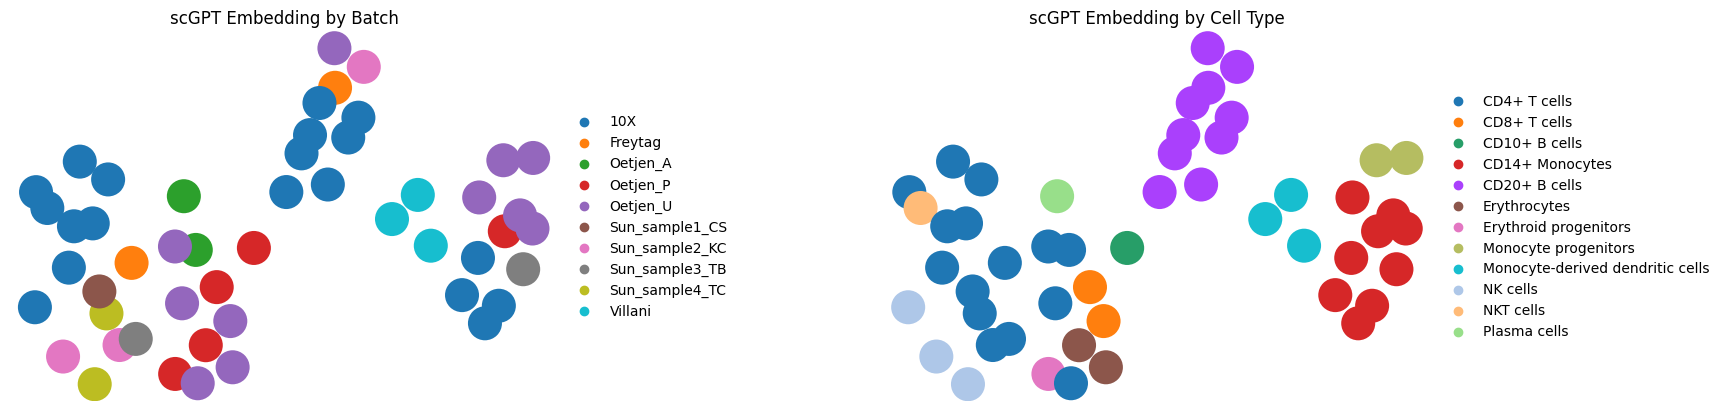


UMAP visualization completed successfully.
Figure saved to: outputs/scGPT_Batch_Integration_UMAP.png


In [21]:
# ============================================================
# Step 17. Visualize scGPT embeddings by batch and cell type
# ============================================================

import matplotlib.pyplot as plt
import scanpy as sc

print("=" * 60)
print("Computing UMAP from scGPT Embeddings")
print("=" * 60)

# Create a copy for visualization
adata_batch_umap = adata_batch_small.copy()

# Build the neighborhood graph using scGPT embeddings
sc.pp.neighbors(
    adata_batch_umap,
    use_rep="X_scGPT",
    n_neighbors=10
)

# Compute UMAP coordinates
sc.tl.umap(
    adata_batch_umap,
    random_state=42
)

# Plot UMAP colored by batch and cell type
sc.pl.umap(
    adata_batch_umap,
    color=[BATCH_KEY, LABEL_KEY],
    title=[
        "scGPT Embedding by Batch",
        "scGPT Embedding by Cell Type"
    ],
    frameon=False,
    wspace=0.45,
    show=False
)

# Save the figure
plt.savefig(
    "outputs/scGPT_Batch_Integration_UMAP.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nUMAP visualization completed successfully.")
print(
    "Figure saved to: "
    "outputs/scGPT_Batch_Integration_UMAP.png"
)

In [22]:
# ============================================================
# Step 18. Save the integrated AnnData object
# ============================================================

print("=" * 60)
print("Saving Integrated Dataset")
print("=" * 60)

output_file = "outputs/scGPT_batch_integrated.h5ad"

adata_batch_umap.write(output_file)

print("\nDataset saved successfully.")
print(f"File: {output_file}")

print("\nDataset summary")
print("----------------------------")
print(f"Cells      : {adata_batch_umap.n_obs}")
print(f"Genes      : {adata_batch_umap.n_vars}")
print(f"Embedding  : {adata_batch_umap.obsm['X_scGPT'].shape}")

Saving Integrated Dataset

Dataset saved successfully.
File: outputs/scGPT_batch_integrated.h5ad

Dataset summary
----------------------------
Cells      : 50
Genes      : 12077
Embedding  : (50, 512)


In [23]:
# ============================================================
# Step 19. Configure the scGPT perturbation prediction workflow
# ============================================================

# Use the course Adamson perturbation dataset
USE_SAMPLE_DATA = True

# Custom perturbation dataset
# Place the file inside the sample_data directory when used
MY_H5AD_NAME = "my_perturb.h5ad"

# Target genes for perturbation prediction
PERT_GENES = [
    "BHLHE40",
    "CREB1"
]

# Course sample dataset
SAMPLE_H5AD_NAME = "adamson/perturb_processed.h5ad"

# Number of control cells used to generate each prediction
POOL_SIZE = 10

# Keep the batch size at 1 for low-memory CPU inference
BATCH_SIZE = 1

print("=" * 60)
print("scGPT Perturbation Prediction Configuration")
print("=" * 60)

print(f"Use sample dataset : {USE_SAMPLE_DATA}")
print(f"Sample dataset     : {SAMPLE_H5AD_NAME}")
print(f"Custom dataset     : {MY_H5AD_NAME}")
print(f"Target genes       : {PERT_GENES}")
print(f"Control pool size  : {POOL_SIZE}")
print(f"Inference batch size: {BATCH_SIZE}")

scGPT Perturbation Prediction Configuration
Use sample dataset : True
Sample dataset     : adamson/perturb_processed.h5ad
Custom dataset     : my_perturb.h5ad
Target genes       : ['BHLHE40', 'CREB1']
Control pool size  : 10
Inference batch size: 1


In [29]:
# ============================================================
# Step 20. Define perturbation prediction utilities
# ============================================================

import os
import io
import json
import time
import gc
import contextlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")
matplotlib.rcParams["axes.unicode_minus"] = False

# Disable external experiment tracking and unnecessary warnings
os.environ.setdefault("WANDB_MODE", "disabled")
os.environ.setdefault("KMP_WARNINGS", "off")

# Reduce unnecessary Scanpy output
sc.settings.verbosity = 0

# Reduce scGPT log messages
import logging
logging.getLogger("scGPT").setLevel(logging.ERROR)

# Limit CPU threads to reduce memory usage
torch.set_num_threads(2)


def find_sample_data(probe):
    """
    Search for the requested file in sample_data
    and in the current or parent directories.
    """
    current_dir = Path.cwd().resolve()
    candidates = []

    for base_dir in [current_dir, *current_dir.parents]:
        candidates.extend([
            base_dir / "sample_data",
            base_dir
        ])

    for candidate in candidates:
        if (candidate / probe).exists():
            return candidate

    return current_dir / "sample_data"


def _ensure_weights():
    """
    Check and return the available pretrained model paths.
    """
    from scgpt_rep import ensure_weights

    return ensure_weights()


def model_ready():
    """
    Return True when the pretrained model files are ready.
    """
    try:
        return bool(_ensure_weights().get("ready"))

    except Exception:
        return False


def _load_perturbation_model(adata):
    """
    Load the Adamson fine-tuned scGPT perturbation model.

    Returns
    -------
    model
        The pretrained TransformerGenerator model.
    gene_ids
        Vocabulary indices corresponding to dataset genes.
    genes
        Dataset gene symbols.
    """
    from scgpt.model import TransformerGenerator
    from scgpt.tokenizer.gene_tokenizer import GeneVocab

    model_directory = Path(
        _ensure_weights()["finetuned_perturbation_dir"]
    )

    captured_output = io.StringIO()

    with contextlib.redirect_stdout(captured_output), \
         contextlib.redirect_stderr(captured_output):

        vocab = GeneVocab.from_file(
            str(model_directory / "vocab.json")
        )

        for token in ["<pad>", "<cls>", "<eoc>"]:
            if token not in vocab:
                vocab.append_token(token)

        vocab.set_default_index(
            vocab["<pad>"]
        )

        genes = (
            adata.var["gene_name"]
            .astype(str)
            .tolist()
        )

        gene_ids = np.array(
            [
                vocab[gene]
                if gene in vocab
                else vocab["<pad>"]
                for gene in genes
            ],
            dtype=int
        )

        with open(
            model_directory / "args.json",
            "r"
        ) as file:
            config = json.load(file)

        model = TransformerGenerator(
            len(vocab),
            config["embsize"],
            config["nheads"],
            config["d_hid"],
            config["nlayers"],
            nlayers_cls=config.get(
                "n_layers_cls",
                3
            ),
            n_cls=1,
            vocab=vocab,
            dropout=0.2,
            pad_token="<pad>",
            pad_value=0,
            pert_pad_id=0,
            use_fast_transformer=False
        )

        state_dict = torch.load(
            str(model_directory / "best_model.pt"),
            map_location="cpu"
        )

        # Adapt older attention-layer parameter names
        state_dict = {
            key.replace("Wqkv.", "in_proj_"): value
            for key, value in state_dict.items()
        }

        model_state = model.state_dict()

        compatible_state = {
            key: value
            for key, value in state_dict.items()
            if key in model_state
            and value.shape == model_state[key].shape
        }

        model_state.update(
            compatible_state
        )

        model.load_state_dict(
            model_state
        )

        model.eval()
        model.to("cpu")

    return model, gene_ids, genes


def scgpt_predict_perturbation(
    adata,
    perturbation_genes,
    pool_size=10,
    batch_size=1
):
    """
    Predict full gene-expression profiles after perturbation.

    Parameters
    ----------
    adata
        Adamson perturbation AnnData object.
    perturbation_genes
        List of target perturbation genes.
    pool_size
        Number of control cells used per perturbation.
    batch_size
        CPU inference batch size.

    Returns
    -------
    predictions
        Dictionary mapping each perturbation gene
        to its predicted expression vector.
    genes
        Gene symbols corresponding to each vector position.
    control_adata
        Control-cell subset.
    """
    from torch_geometric.loader import DataLoader
    from gears.utils import (
        create_cell_graph_dataset_for_prediction
    )

    model, gene_ids, genes = _load_perturbation_model(
        adata
    )

    control_adata = adata[
        adata.obs["condition"] == "ctrl"
    ].copy()

    if control_adata.n_obs == 0:
        raise ValueError(
            "No control cells were found in the dataset."
        )

    predictions = {}

    for perturbation_gene in perturbation_genes:

        print(
            f"Predicting perturbation: "
            f"{perturbation_gene}"
        )

        captured_output = io.StringIO()

        with contextlib.redirect_stdout(captured_output), \
             contextlib.redirect_stderr(captured_output):

            cell_graphs = (
                create_cell_graph_dataset_for_prediction(
                    [perturbation_gene],
                    control_adata,
                    genes,
                    "cpu",
                    num_samples=pool_size
                )
            )

            loader = DataLoader(
                cell_graphs,
                batch_size=batch_size,
                shuffle=False
            )

            batch_predictions = []

            with torch.no_grad():

                for batch_data in loader:

                    output = model.pred_perturb(
                        batch_data,
                        "all",
                        gene_ids=gene_ids,
                        amp=False
                    )

                    batch_predictions.append(
                        output.detach().cpu()
                    )

            predictions[perturbation_gene] = (
                torch.cat(
                    batch_predictions,
                    dim=0
                )
                .mean(dim=0)
                .numpy()
            )

        gc.collect()

    return predictions, genes, control_adata


print("=" * 60)
print("Perturbation Prediction Utilities")
print("=" * 60)

print("CPU threads:", torch.get_num_threads())
print(
    "Model status:",
    "Ready" if model_ready() else "Not ready"
)
print("Utility functions initialized successfully.")

Perturbation Prediction Utilities
CPU threads: 2
Model status: Ready
Utility functions initialized successfully.


In [30]:
# ============================================================
# Step 21. Load and inspect the perturbation dataset
# ============================================================

print("=" * 60)
print("Loading Perturbation Dataset")
print("=" * 60)

dataset_name = (
    SAMPLE_H5AD_NAME
    if USE_SAMPLE_DATA
    else MY_H5AD_NAME
)

H5AD = (
    find_sample_data(dataset_name)
    / dataset_name
)

OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Dataset path: {H5AD}")

if not H5AD.exists():
    raise FileNotFoundError(
        f"Dataset not found: {H5AD}"
    )

adata = sc.read_h5ad(
    H5AD
)

print("\nDataset loaded successfully.")
print(f"Cells : {adata.n_obs}")
print(f"Genes : {adata.n_vars}")

print("\nObservation columns:")
print(list(adata.obs.columns))

print("\nVariable columns:")
print(list(adata.var.columns))

print("\nAvailable conditions:")
print(
    adata.obs["condition"]
    .value_counts()
    .head(15)
)

Loading Perturbation Dataset
Dataset path: /workspace/sample_data/adamson/perturb_processed.h5ad

Dataset loaded successfully.
Cells : 500
Genes : 5060

Observation columns:
['condition', 'cell_type', 'dose_val', 'control', 'condition_name']

Variable columns:
['gene_name']

Available conditions:
condition
ctrl            456
BHLHE40+ctrl     13
OST4+ctrl        12
CREB1+ctrl       10
ZNF326+ctrl       6
DDIT3+ctrl        3
Name: count, dtype: int64


In [31]:
# ============================================================
# Step 22. Validate perturbations and required metadata
# ============================================================

print("=" * 60)
print("Perturbation Data Validation")
print("=" * 60)

# Check required observation metadata
print("\n1. Required observation fields")

required_obs_columns = [
    "condition",
    "condition_name"
]

for column in required_obs_columns:
    print(
        f"{column}:",
        "Found"
        if column in adata.obs.columns
        else "Missing"
    )

missing_obs_columns = [
    column
    for column in required_obs_columns
    if column not in adata.obs.columns
]

if missing_obs_columns:
    raise KeyError(
        "Missing required observation columns: "
        f"{missing_obs_columns}"
    )

# Check differential-expression metadata
print("\n2. Differential-expression metadata")

de_key = "top_non_dropout_de_20"

print(
    f"{de_key}:",
    "Found"
    if de_key in adata.uns
    else "Missing"
)

if de_key not in adata.uns:
    raise KeyError(
        f"Missing required key in adata.uns: {de_key}"
    )

# Check gene-symbol metadata
print("\n3. Gene-symbol column")

if "gene_name" in adata.var.columns:
    print("gene_name: Found")
else:
    raise KeyError(
        "Missing adata.var['gene_name']."
    )

# Identify perturbation genes in the dataset
print("\n4. Available perturbations")

conditions = [
    condition
    for condition in adata.obs["condition"].unique()
    if condition != "ctrl"
]

available_perturbations = sorted({
    condition.split("+")[0]
    for condition in conditions
})

print("Available perturbation genes:")
print(available_perturbations)

gene_set = set(
    adata.var["gene_name"]
    .astype(str)
)

RUN_PERTS = [
    gene
    for gene in PERT_GENES
    if gene in available_perturbations
    and gene in gene_set
]

unavailable_perturbations = [
    gene
    for gene in PERT_GENES
    if gene not in available_perturbations
]

if unavailable_perturbations:
    print(
        "\nUnavailable requested perturbations:"
    )
    print(
        unavailable_perturbations
    )

if not RUN_PERTS:

    if not available_perturbations:
        raise ValueError(
            "No perturbation genes are available."
        )

    RUN_PERTS = available_perturbations[:2]

    print("\nAutomatically selected perturbations:")
    print(RUN_PERTS)

print("\nSelected perturbations:")
print(RUN_PERTS)

# Check control cells
print("\n5. Control cells")

number_of_control_cells = (
    adata.obs["condition"]
    .eq("ctrl")
    .sum()
)

print(
    "Number of control cells:",
    number_of_control_cells
)

if number_of_control_cells == 0:
    raise ValueError(
        "No control cells were found."
    )

# Check pretrained model
print("\n6. Pretrained model")

print(
    "Model status:",
    "Ready" if model_ready() else "Not ready"
)

if not model_ready():
    raise RuntimeError(
        "The pretrained perturbation model is not ready."
    )

print("\nValidation completed successfully.")

Perturbation Data Validation

1. Required observation fields
condition: Found
condition_name: Found

2. Differential-expression metadata
top_non_dropout_de_20: Found

3. Gene-symbol column
gene_name: Found

4. Available perturbations
Available perturbation genes:
['BHLHE40', 'CREB1', 'DDIT3', 'OST4', 'ZNF326']

Selected perturbations:
['BHLHE40', 'CREB1']

5. Control cells
Number of control cells: 456

6. Pretrained model
Model status: Ready

Validation completed successfully.


In [32]:
# ============================================================
# Step 23. Run scGPT perturbation prediction
# ============================================================

print("=" * 60)
print("Running scGPT Perturbation Prediction")
print("=" * 60)

print(f"Dataset shape        : {adata.shape}")
print(f"Selected targets     : {RUN_PERTS}")
print(f"Control pool size    : {POOL_SIZE}")
print(f"Inference batch size : {BATCH_SIZE}")

# Release unused memory before inference
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

if torch.backends.mps.is_available():
    torch.mps.empty_cache()

start_time = time.time()

preds, genes, ctrl = scgpt_predict_perturbation(
    adata,
    RUN_PERTS,
    pool_size=POOL_SIZE,
    batch_size=BATCH_SIZE
)

elapsed_time = time.time() - start_time

# Calculate the mean control expression profile
ctrl_mean = np.asarray(
    ctrl.X.mean(axis=0)
).flatten()

# Create downstream gene mappings
gene2idx = {
    gene: index
    for index, gene in enumerate(genes)
}

gene_raw2id = dict(
    zip(
        adata.var.index.values,
        adata.var["gene_name"].values
    )
)

cond2name = dict(
    adata.obs[
        ["condition", "condition_name"]
    ].values
)

print("\nPrediction completed successfully.")
print(f"Elapsed time: {elapsed_time:.1f} seconds")
print("Predicted perturbations:", list(preds.keys()))
print("Number of control cells:", ctrl.n_obs)
print("Genes per prediction:", len(genes))

for perturbation_gene, prediction in preds.items():

    print(
        f"{perturbation_gene}: "
        f"prediction shape = {prediction.shape}"
    )

gc.collect()

Running scGPT Perturbation Prediction
Dataset shape        : (500, 5060)
Selected targets     : ['BHLHE40', 'CREB1']
Control pool size    : 10
Inference batch size : 1
Predicting perturbation: BHLHE40
Predicting perturbation: CREB1

Prediction completed successfully.
Elapsed time: 621.8 seconds
Predicted perturbations: ['BHLHE40', 'CREB1']
Number of control cells: 456
Genes per prediction: 5060
BHLHE40: prediction shape = (5060,)
CREB1: prediction shape = (5060,)


0

Top-20 Differential Expression Comparison
Perturbation: BHLHE40
Condition   : BHLHE40+ctrl

Top-20 DE gene comparison:


,gene,true_delta,predicted_delta
0,SLC25A6,-2.080309,0.190644
1,CD99,-0.901775,0.175199
2,RPS27,0.754097,-0.316058
3,RPS10,0.787630,-0.325190
4,RPL37A,0.568800,-0.471550
5,BHLHE40,-0.498692,-0.474145
6,DDIT4,-0.932066,0.429943
7,FTH1,-0.437115,0.125715
8,RGS16,-0.523827,0.069397
9,RPL28,0.458160,-0.348345


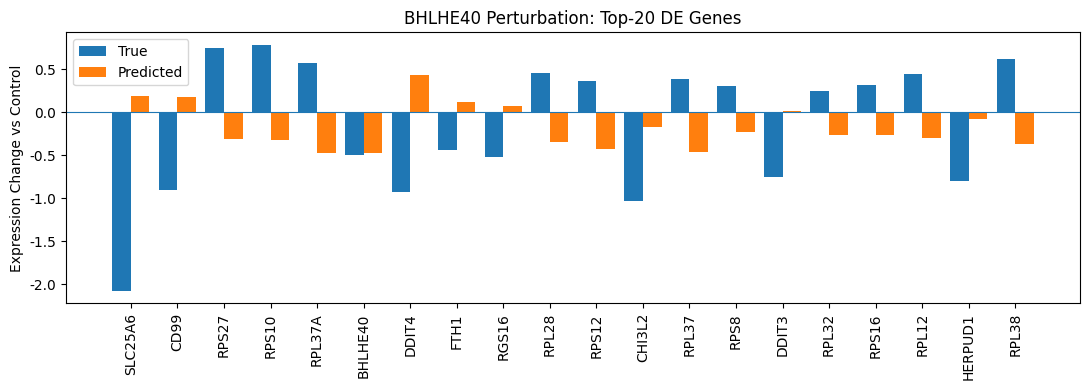


Figure saved successfully.
File: /workspace/outputs/scGPT_BHLHE40_Top20_DE_True_vs_Predicted.png


In [33]:
# ============================================================
# Step 24. Compare true and predicted changes for top-20 DE genes
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print("Top-20 Differential Expression Comparison")
print("=" * 60)

# Use the first selected perturbation
perturbation_gene = RUN_PERTS[0]
condition = f"{perturbation_gene}+ctrl"

print(f"Perturbation: {perturbation_gene}")
print(f"Condition   : {condition}")

# Calculate the mean expression of experimentally perturbed cells
true_mean = np.asarray(
    adata[
        adata.obs["condition"] == condition
    ].X.mean(axis=0)
).flatten()

# Retrieve the top-20 non-dropout DE genes
raw_de_genes = adata.uns[
    "top_non_dropout_de_20"
][
    cond2name[condition]
]

de_gene_names = [
    gene_raw2id[raw_gene]
    for raw_gene in raw_de_genes
    if gene_raw2id.get(raw_gene) in gene2idx
]

# Convert gene names to expression-vector indices
de_gene_indices = [
    gene2idx[gene]
    for gene in de_gene_names
]

# Calculate expression changes relative to control cells
comparison_df = pd.DataFrame({
    "gene": de_gene_names,
    "true_delta": (
        true_mean[de_gene_indices]
        - ctrl_mean[de_gene_indices]
    ),
    "predicted_delta": (
        preds[perturbation_gene][de_gene_indices]
        - ctrl_mean[de_gene_indices]
    )
})

print("\nTop-20 DE gene comparison:")
display(comparison_df)

# Plot true and predicted expression changes
x_positions = np.arange(
    len(comparison_df)
)

bar_width = 0.4

fig, ax = plt.subplots(
    figsize=(11, 4)
)

ax.bar(
    x_positions - bar_width / 2,
    comparison_df["true_delta"],
    bar_width,
    label="True"
)

ax.bar(
    x_positions + bar_width / 2,
    comparison_df["predicted_delta"],
    bar_width,
    label="Predicted"
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    comparison_df["gene"],
    rotation=90
)

ax.set_ylabel(
    "Expression Change vs Control"
)

ax.set_title(
    f"{perturbation_gene} Perturbation: "
    "Top-20 DE Genes"
)

ax.legend()

plt.tight_layout()

# Save the figure
output_figure = (
    OUTPUT_DIR
    / f"scGPT_{perturbation_gene}_Top20_DE_True_vs_Predicted.png"
)

plt.savefig(
    output_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nFigure saved successfully.")
print(f"File: {output_figure}")

Prediction Correlation


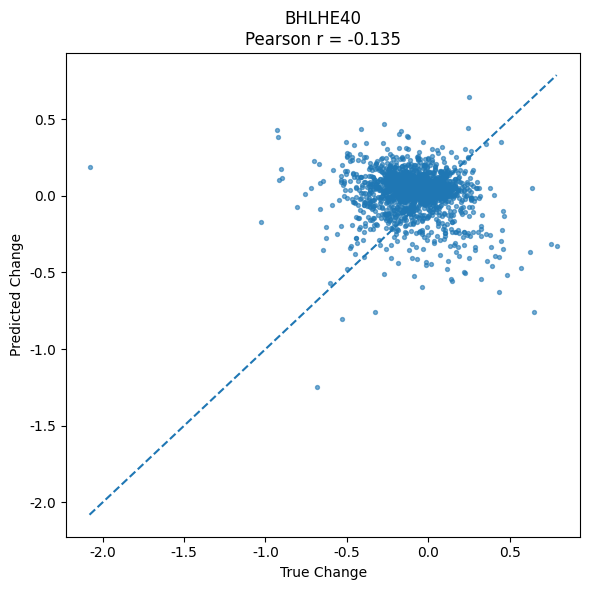


Figure saved successfully.
/workspace/outputs/scGPT_BHLHE40_Correlation.png


In [34]:
# ============================================================
# Step 25. Prediction vs Ground Truth Correlation
# ============================================================

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print("=" * 60)
print("Prediction Correlation")
print("=" * 60)

perturbation_gene = RUN_PERTS[0]
condition = f"{perturbation_gene}+ctrl"

true_mean = (
    adata[
        adata.obs["condition"] == condition
    ].X.mean(axis=0)
)

true_mean = np.asarray(true_mean).flatten()

true_delta = true_mean - ctrl_mean
pred_delta = preds[perturbation_gene] - ctrl_mean

corr, _ = pearsonr(true_delta, pred_delta)

plt.figure(figsize=(6,6))

plt.scatter(
    true_delta,
    pred_delta,
    s=8,
    alpha=0.6
)

xmin = min(true_delta.min(), pred_delta.min())
xmax = max(true_delta.max(), pred_delta.max())

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    "--"
)

plt.xlabel("True Change")
plt.ylabel("Predicted Change")

plt.title(
    f"{perturbation_gene}\nPearson r = {corr:.3f}"
)

plt.tight_layout()

output_file = (
    OUTPUT_DIR
    / f"scGPT_{perturbation_gene}_Correlation.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print()
print("Figure saved successfully.")
print(output_file)

Top-20 DE Gene Correlation Analysis
BHLHE40: 20 DE genes, Pearson r = -0.754
CREB1: 20 DE genes, Pearson r = -0.836


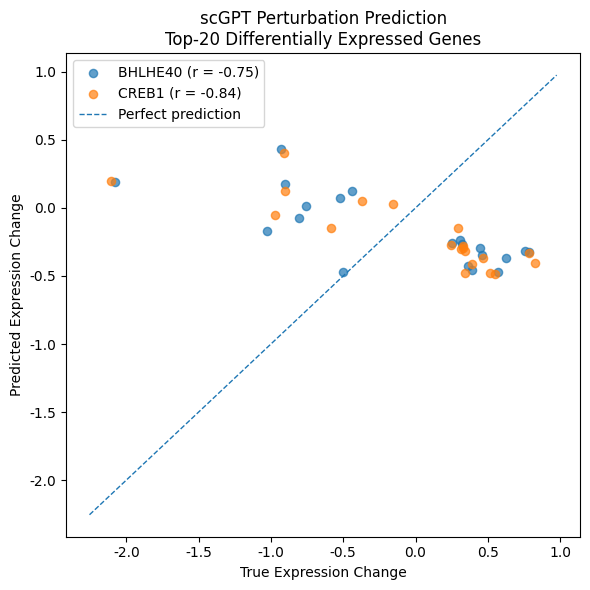


Figure saved successfully.
File: /workspace/outputs/scGPT_Perturbation_Top20_DE_Correlation.png


In [35]:
# ============================================================
# Step 26. Compare predicted and true changes for both perturbations
# using the top-20 differentially expressed genes
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print("=" * 60)
print("Top-20 DE Gene Correlation Analysis")
print("=" * 60)

fig, ax = plt.subplots(figsize=(6, 6))

available_conditions = set(
    adata.obs["condition"].astype(str)
)

correlation_results = {}

for perturbation_gene in RUN_PERTS:

    condition = f"{perturbation_gene}+ctrl"

    if condition not in available_conditions:
        print(
            f"Skipped {perturbation_gene}: "
            f"condition '{condition}' was not found."
        )
        continue

    # Calculate the experimental mean expression profile
    true_mean = np.asarray(
        adata[
            adata.obs["condition"] == condition
        ].X.mean(axis=0)
    ).flatten()

    # Retrieve the top-20 non-dropout DE genes
    raw_de_genes = adata.uns[
        "top_non_dropout_de_20"
    ][
        cond2name[condition]
    ]

    de_gene_names = [
        gene_raw2id[raw_gene]
        for raw_gene in raw_de_genes
        if gene_raw2id.get(raw_gene) in gene2idx
    ]

    de_gene_indices = [
        gene2idx[gene]
        for gene in de_gene_names
    ]

    # Calculate true and predicted changes relative to control
    true_delta = (
        true_mean[de_gene_indices]
        - ctrl_mean[de_gene_indices]
    )

    predicted_delta = (
        preds[perturbation_gene][de_gene_indices]
        - ctrl_mean[de_gene_indices]
    )

    # Calculate Pearson correlation
    if len(de_gene_indices) > 2:
        correlation = pearsonr(
            true_delta,
            predicted_delta
        )[0]
    else:
        correlation = float("nan")

    correlation_results[perturbation_gene] = correlation

    ax.scatter(
        true_delta,
        predicted_delta,
        s=35,
        alpha=0.7,
        label=(
            f"{perturbation_gene} "
            f"(r = {correlation:.2f})"
        )
    )

    print(
        f"{perturbation_gene}: "
        f"{len(de_gene_indices)} DE genes, "
        f"Pearson r = {correlation:.3f}"
    )

# Add the ideal prediction line
x_limits = ax.get_xlim()
y_limits = ax.get_ylim()

minimum_value = min(
    x_limits[0],
    y_limits[0]
)

maximum_value = max(
    x_limits[1],
    y_limits[1]
)

ax.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)

ax.set_xlabel("True Expression Change")
ax.set_ylabel("Predicted Expression Change")

ax.set_title(
    "scGPT Perturbation Prediction\n"
    "Top-20 Differentially Expressed Genes"
)

ax.legend()
plt.tight_layout()

# Save the figure
output_figure = (
    OUTPUT_DIR
    / "scGPT_Perturbation_Top20_DE_Correlation.png"
)

plt.savefig(
    output_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nFigure saved successfully.")
print(f"File: {output_figure}")

In [36]:
# ============================================================
# Step 27. Configure the GRN and gene-embedding workflow
# ============================================================

# Use the course immune-cell dataset
USE_GRN_SAMPLE_DATA = True

# Custom dataset
# Place the file inside the sample_data directory when used
GRN_MY_H5AD_NAME = "my_data.h5ad"

# Course sample dataset
GRN_SAMPLE_H5AD_NAME = "Immune_ALL_human.h5ad"

# Cell-type annotation column
GRN_LABEL_KEY = "final_annotation"

# Low-memory GRN settings
N_HVG_GRN = 600
GRN_RESOLUTION = 20
MIN_PROGRAM_GENES = 5

print("=" * 60)
print("scGPT GRN and Gene-Embedding Configuration")
print("=" * 60)

print(f"Use sample dataset      : {USE_GRN_SAMPLE_DATA}")
print(f"Sample dataset          : {GRN_SAMPLE_H5AD_NAME}")
print(f"Custom dataset          : {GRN_MY_H5AD_NAME}")
print(f"Cell-type column        : {GRN_LABEL_KEY}")
print(f"Highly variable genes   : {N_HVG_GRN}")
print(f"Clustering resolution   : {GRN_RESOLUTION}")
print(f"Minimum program size    : {MIN_PROGRAM_GENES}")

scGPT GRN and Gene-Embedding Configuration
Use sample dataset      : True
Sample dataset          : Immune_ALL_human.h5ad
Custom dataset          : my_data.h5ad
Cell-type column        : final_annotation
Highly variable genes   : 600
Clustering resolution   : 20
Minimum program size    : 5


In [37]:
# ============================================================
# Step 28. Load dataset and prepare highly variable genes
# ============================================================

import scanpy as sc
import os

print("=" * 60)
print("Loading Dataset for Gene Embedding")
print("=" * 60)

# Load dataset
if USE_GRN_SAMPLE_DATA:
    data_path = os.path.join(
        "sample_data",
        GRN_SAMPLE_H5AD_NAME
    )
else:
    data_path = os.path.join(
        "sample_data",
        GRN_MY_H5AD_NAME
    )

adata = sc.read_h5ad(data_path)

print(f"Dataset shape : {adata.shape}")
print(f"Cell types    : {adata.obs[GRN_LABEL_KEY].nunique()}")

# Keep highly variable genes
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=N_HVG_GRN,
    flavor="seurat_v3"
)

adata_hvg = adata[:, adata.var["highly_variable"]].copy()

print()
print("After HVG selection")
print(f"HVG dataset shape : {adata_hvg.shape}")
print(f"Selected genes    : {adata_hvg.n_vars}")

Loading Dataset for Gene Embedding
Dataset shape : (500, 12303)
Cell types    : 16

After HVG selection
HVG dataset shape : (500, 600)
Selected genes    : 600


In [38]:
# ============================================================
# Step 29. Extract pretrained scGPT gene embeddings
# ============================================================

import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

print("=" * 60)
print("Extracting Pretrained scGPT Gene Embeddings")
print("=" * 60)

# Release unused memory
gc.collect()

# Locate pretrained scGPT files
from scgpt_rep import ensure_weights

weight_info = ensure_weights()

if not weight_info.get("ready", False):
    raise RuntimeError(
        "The pretrained scGPT model files are not ready."
    )

# Use the pretrained whole-human model
model_directory = Path(
    weight_info["scgpt_human_dir"]
)

vocab_file = model_directory / "vocab.json"
model_file = model_directory / "best_model.pt"

print(f"Model directory : {model_directory}")
print(f"Vocabulary file : {vocab_file.name}")
print(f"Model file      : {model_file.name}")

if not vocab_file.exists():
    raise FileNotFoundError(
        f"Vocabulary file not found: {vocab_file}"
    )

if not model_file.exists():
    raise FileNotFoundError(
        f"Model file not found: {model_file}"
    )

# Load the gene vocabulary
with open(vocab_file, "r") as file:
    vocab_data = json.load(file)

# Support both dictionary-style vocabulary formats
if isinstance(vocab_data, dict) and "stoi" in vocab_data:
    gene_to_id = vocab_data["stoi"]

elif isinstance(vocab_data, dict):
    gene_to_id = vocab_data

else:
    raise TypeError(
        "Unsupported vocabulary format."
    )

# Load pretrained model weights on CPU
state_dict = torch.load(
    model_file,
    map_location="cpu"
)

# Find the gene-token embedding matrix automatically
candidate_keys = [
    key
    for key in state_dict.keys()
    if key.endswith("encoder.embedding.weight")
    or key.endswith("gene_encoder.embedding.weight")
]

if not candidate_keys:
    candidate_keys = [
        key
        for key in state_dict.keys()
        if "embedding.weight" in key
        and state_dict[key].ndim == 2
        and state_dict[key].shape[1] == 512
    ]

if not candidate_keys:
    raise KeyError(
        "The gene-embedding weight matrix could not be found "
        "in the pretrained model."
    )

embedding_key = candidate_keys[0]

gene_embedding_matrix = (
    state_dict[embedding_key]
    .detach()
    .cpu()
    .numpy()
)

print(f"\nEmbedding weight key : {embedding_key}")
print(
    "Complete embedding matrix shape:",
    gene_embedding_matrix.shape
)

# Obtain gene symbols from the HVG dataset
if "gene_name" in adata_hvg.var.columns:
    hvg_genes = (
        adata_hvg.var["gene_name"]
        .astype(str)
        .tolist()
    )
else:
    hvg_genes = (
        adata_hvg.var_names
        .astype(str)
        .tolist()
    )

# Keep only genes found in the pretrained vocabulary
matched_genes = [
    gene
    for gene in hvg_genes
    if gene in gene_to_id
    and int(gene_to_id[gene]) < gene_embedding_matrix.shape[0]
]

missing_genes = [
    gene
    for gene in hvg_genes
    if gene not in matched_genes
]

if len(matched_genes) < 10:
    raise ValueError(
        "Too few HVGs matched the pretrained scGPT vocabulary."
    )

# Extract the embedding vector for every matched gene
matched_gene_ids = np.array(
    [
        int(gene_to_id[gene])
        for gene in matched_genes
    ],
    dtype=int
)

grn_gene_embeddings = gene_embedding_matrix[
    matched_gene_ids
].copy()

# Create an AnnData object with genes as observations
grn_adata = sc.AnnData(
    X=grn_gene_embeddings
)

grn_adata.obs_names = matched_genes
grn_adata.obs["gene"] = matched_genes
grn_adata.obs["vocab_id"] = matched_gene_ids

# Save the embeddings in a convenient table
gene_embedding_df = pd.DataFrame(
    grn_gene_embeddings,
    index=matched_genes,
    columns=[
        f"embedding_{dimension}"
        for dimension in range(
            grn_gene_embeddings.shape[1]
        )
    ]
)

print("\nGene embedding extraction completed.")
print(f"Requested HVGs      : {len(hvg_genes)}")
print(f"Matched HVGs        : {len(matched_genes)}")
print(f"Unmatched HVGs      : {len(missing_genes)}")
print(
    "Selected embedding shape:",
    grn_gene_embeddings.shape
)

# Release the complete model weight dictionary
del state_dict
del gene_embedding_matrix
gc.collect()

Extracting Pretrained scGPT Gene Embeddings
Model directory : /run/.w/scGPT_human
Vocabulary file : vocab.json
Model file      : best_model.pt

Embedding weight key : encoder.embedding.weight
Complete embedding matrix shape: (60697, 512)

Gene embedding extraction completed.
Requested HVGs      : 600
Matched HVGs        : 589
Unmatched HVGs      : 11
Selected embedding shape: (589, 512)


9

Building Gene Similarity Graph

Gene-program summary
------------------------------
Genes analyzed       : 589
Embedding dimensions : 512
Number of programs   : 149

Genes per program:
gene_program
0      11
1       9
2       9
3       8
4       7
       ..
144     2
145     2
146     2
147     1
148     1
Name: count, Length: 149, dtype: int64


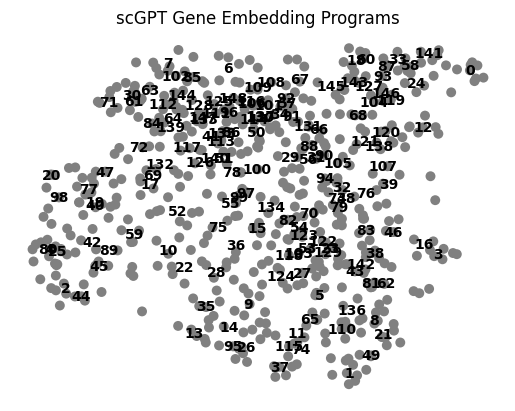


Figure saved successfully.
File: /workspace/outputs/scGPT_Gene_Embedding_Programs_UMAP.png


In [39]:
# ============================================================
# Step 30. Build gene similarity graph and identify gene programs
# ============================================================

import scanpy as sc
import matplotlib.pyplot as plt

print("=" * 60)
print("Building Gene Similarity Graph")
print("=" * 60)

# Use gene embeddings as the representation
grn_adata.obsm["X_scGPT_gene"] = grn_gene_embeddings

# Build a k-nearest-neighbor graph in gene-embedding space
sc.pp.neighbors(
    grn_adata,
    use_rep="X_scGPT_gene",
    n_neighbors=10,
    metric="cosine"
)

# Compute a 2D UMAP representation of genes
sc.tl.umap(
    grn_adata,
    random_state=42
)

# Cluster genes into putative gene programs
sc.tl.leiden(
    grn_adata,
    resolution=GRN_RESOLUTION,
    key_added="gene_program",
    random_state=42
)

# Count genes in each program
program_counts = (
    grn_adata.obs["gene_program"]
    .value_counts()
    .sort_index()
)

print("\nGene-program summary")
print("------------------------------")
print(f"Genes analyzed       : {grn_adata.n_obs}")
print(f"Embedding dimensions : {grn_adata.n_vars}")
print(f"Number of programs   : {grn_adata.obs['gene_program'].nunique()}")

print("\nGenes per program:")
print(program_counts)

# Plot the gene embedding UMAP
sc.pl.umap(
    grn_adata,
    color="gene_program",
    title="scGPT Gene Embedding Programs",
    frameon=False,
    legend_loc="on data",
    show=False
)

output_figure = (
    OUTPUT_DIR
    / "scGPT_Gene_Embedding_Programs_UMAP.png"
)

plt.savefig(
    output_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("\nFigure saved successfully.")
print(f"File: {output_figure}")

In [40]:
# ============================================================
# Step 31. Export Gene Programs
# ============================================================

import pandas as pd

print("=" * 60)
print("Exporting Gene Programs")
print("=" * 60)

program_table = pd.DataFrame({
    "Gene": grn_adata.obs_names,
    "Program": grn_adata.obs["gene_program"].astype(str)
})

program_table = program_table.sort_values(
    ["Program", "Gene"]
)

output_csv = OUTPUT_DIR / "scGPT_Gene_Programs.csv"

program_table.to_csv(
    output_csv,
    index=False
)

print(program_table.head(20))

print()
print("Gene programs exported successfully.")
print(f"File: {output_csv}")
print(f"Total genes: {len(program_table)}")
print(f"Programs: {program_table.Program.nunique()}")

Exporting Gene Programs
              Gene Program
ATP6V0C    ATP6V0C       0
EEF1G        EEF1G       0
GABARAP    GABARAP       0
IFI30        IFI30       0
MRPS24      MRPS24       0
POLD4        POLD4       0
PSMA6        PSMA6       0
RNASEK      RNASEK       0
TRAPPC5    TRAPPC5       0
UBE2V1      UBE2V1       0
UGCG          UGCG       0
CD74          CD74       1
HLA-DMA    HLA-DMA       1
HLA-DMB    HLA-DMB       1
HLA-DPA1  HLA-DPA1       1
HLA-DQA1  HLA-DQA1       1
HLA-DQB1  HLA-DQB1       1
HLA-DRA    HLA-DRA       1
HLA-DRB1  HLA-DRB1       1
HLA-DRB5  HLA-DRB5       1

Gene programs exported successfully.
File: /workspace/outputs/scGPT_Gene_Programs.csv
Total genes: 589
Programs: 149


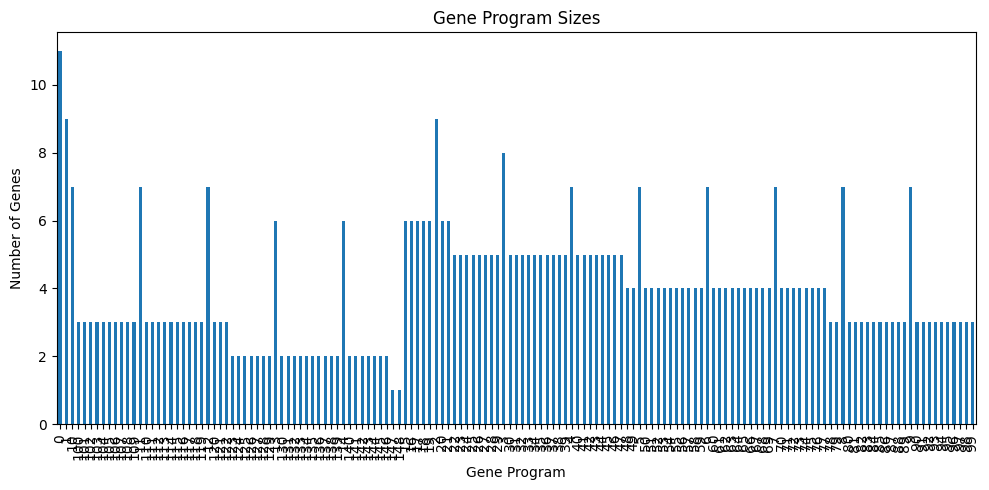

Figure saved:
/workspace/outputs/scGPT_GeneProgram_Size.png


In [41]:
# ============================================================
# Step 32. Largest Gene Programs
# ============================================================

import matplotlib.pyplot as plt

program_sizes = (
    program_table["Program"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

program_sizes.plot(kind="bar")

plt.xlabel("Gene Program")
plt.ylabel("Number of Genes")
plt.title("Gene Program Sizes")

plt.tight_layout()

outfile = OUTPUT_DIR / "scGPT_GeneProgram_Size.png"

plt.savefig(outfile,dpi=300)

plt.show()

print("Figure saved:")
print(outfile)

In [42]:
# ============================================================
# Step 33. Save Gene Embedding AnnData
# ============================================================

outfile = OUTPUT_DIR / "scGPT_GeneEmbedding.h5ad"

grn_adata.write(outfile)

print("=" * 60)
print("Gene embedding dataset saved.")
print("=" * 60)
print(outfile)

Gene embedding dataset saved.
/workspace/outputs/scGPT_GeneEmbedding.h5ad
